Imports and setup

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.config import TARGET_COLUMN, PROCESSED_DATA

import pandas as pd

from src.preprocessing_utils import (
    # chronological_train_test_split,
    create_sequences,
    load_feature_engineered_dataset,
    parse_datetime_index,
    scale_train_test_data,
    split_features_and_target,
)

from src.model_utils import (
    create_lstm_model,
    create_model_comparison_dataframe,
    evaluate_regression_model,
    get_early_stopping_callback,
    plot_actual_vs_predicted,
    plot_training_history,
    save_model_comparison_dataframe,
    train_linear_regression_model,
    train_random_forest_model,
    save_model
)

pd.set_option("display.max_columns", None)

### Model Development and Evaluation

This notebook develops baseline machine learning models and a deep learning model for appliance energy prediction.  
The models are evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

Loading the preprocessed datasets 

In [2]:
train_path = PROCESSED_DATA / "train_feature_engineered_data.csv"
test_path = PROCESSED_DATA / "test_feature_engineered_data.csv"

train_df = load_feature_engineered_dataset(train_path)
test_df = load_feature_engineered_dataset(test_path)

train_df = parse_datetime_index(train_df, "date")
test_df = parse_datetime_index(test_df, "date")

In [3]:
# checking dataset shapes
print("Training set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)

Training set shape: (15779, 21)
Testing set shape: (3945, 21)


Split features and targets

In [4]:
x_train_df, y_train_series = split_features_and_target(train_df, TARGET_COLUMN)
x_test_df, y_test_series = split_features_and_target(test_df, TARGET_COLUMN)

print("X_train shape:", x_train_df.shape)
print("X_test shape:", x_test_df.shape)
print("y_train shape:", y_train_series.shape)
print("y_test shape:", y_test_series.shape)

X_train shape: (15779, 20)
X_test shape: (3945, 20)
y_train shape: (15779,)
y_test shape: (3945,)


Scaling features for baseline and LSTM 

In [5]:
x_train_scaled, x_test_scaled, fitted_scaler = scale_train_test_data(
    x_train=x_train_df,
    x_test=x_test_df,
    scaler_type="standard",
)

print("Scaled X_train shape:", x_train_scaled.shape)
print("Scaled X_test shape:", x_test_scaled.shape)

Scaled X_train shape: (15779, 20)
Scaled X_test shape: (3945, 20)


### Training Linear Regression Model

In [6]:
linear_model = train_linear_regression_model(
    x_train=x_train_scaled,
    y_train=y_train_series.to_numpy(),
)

linear_predictions = linear_model.predict(x_test_scaled)

linear_metrics = evaluate_regression_model(
    y_true=y_test_series.to_numpy(),
    y_pred=linear_predictions,
)

linear_metrics

{'MAE': 11.61, 'RMSE': 18.01, 'MAPE': 14.6, 'R2': 0.79}

In [7]:
# saving the Linear Regression model
save_model(
    model=linear_model,
    file_name="linear_regression_model.pkl",
)

### Training Random Forest

In [8]:
random_forest_model = train_random_forest_model(
    x_train=x_train_scaled,
    y_train=y_train_series.to_numpy(),
    n_estimators=200,
    random_state=42,
)

random_forest_predictions = random_forest_model.predict(x_test_scaled)

random_forest_metrics = evaluate_regression_model(
    y_true=y_test_series.to_numpy(),
    y_pred=random_forest_predictions,
)

random_forest_metrics

{'MAE': 11.53, 'RMSE': 17.73, 'MAPE': 14.81, 'R2': 0.79}

In [ ]:
# saving the Random Forest model
save_model(
    model=random_forest_model,
    file_name="random_forest_model.pkl",
)

Plotting the baseline model predictions (Linear regressiond and Random forest)

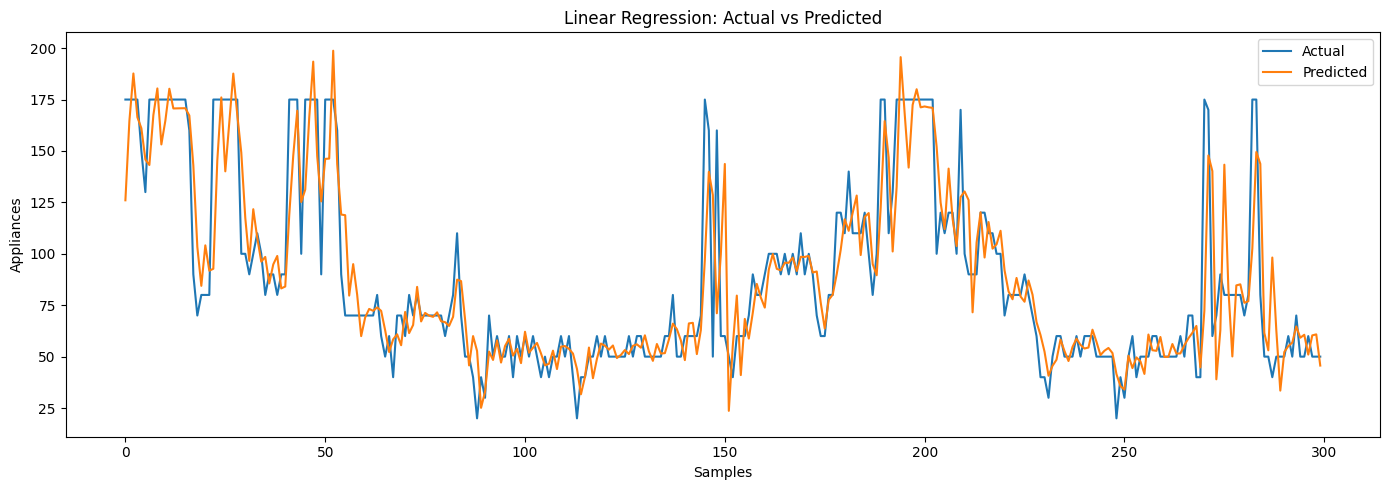

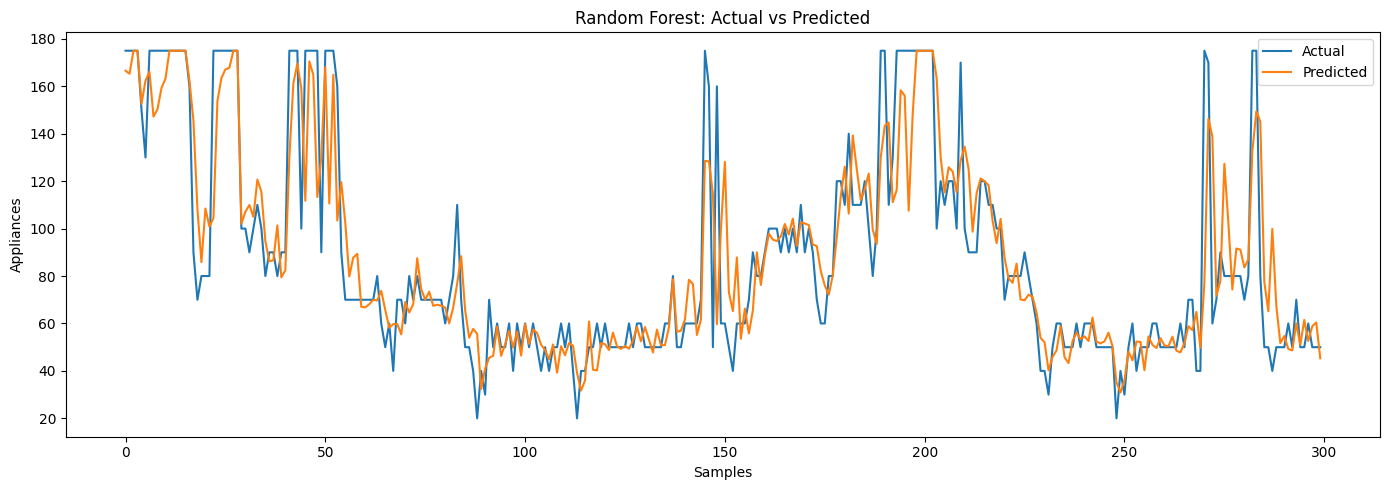

In [10]:
plot_actual_vs_predicted(
    y_true=y_test_series.to_numpy()[:300],
    y_pred=linear_predictions[:300],
    title="Linear Regression: Actual vs Predicted",
    file_name="linear_regression_actual_vs_predicted.png"
)

plot_actual_vs_predicted(
    y_true=y_test_series.to_numpy()[:300],
    y_pred=random_forest_predictions[:300],
    title="Random Forest: Actual vs Predicted",
    file_name="random_forest_actual_vs_predicted.png"
)

### LSTM model

Creating sequences for LSTM model

In [12]:
sequence_length = 6

x_train_seq, y_train_seq = create_sequences(
    x_data=x_train_scaled,
    y_data=y_train_series.to_numpy(),
    sequence_length=sequence_length,
)

x_test_seq, y_test_seq = create_sequences(
    x_data=x_test_scaled,
    y_data=y_test_series.to_numpy(),
    sequence_length=sequence_length,
)

print("x_train_seq shape:", x_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("x_test_seq shape:", x_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)

x_train_seq shape: (15773, 6, 20)
y_train_seq shape: (15773,)
x_test_seq shape: (3939, 6, 20)
y_test_seq shape: (3939,)


Builing the model

In [13]:
lstm_model = create_lstm_model(
    input_shape=(x_train_seq.shape[1], x_train_seq.shape[2]),
    lstm_units=64,
    dropout_rate=0.2,
)

lstm_model.summary()

c:\Users\induw\anaconda3\envs\energy_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,873 (93.25 KB)

 Trainable params: 23,873 (93.25 KB)

 Non-trainable params: 0 (0.00 B)

Training the model

In [14]:
early_stopping = get_early_stopping_callback(patience=5)

history = lstm_model.fit(
    x_train_seq,
    y_train_seq,
    validation_split=0.1,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 4702.3755 - mae: 52.8749 - val_loss: 763.7455 - val_mae: 18.6991
Epoch 2/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 907.7015 - mae: 20.9641 - val_loss: 651.5457 - val_mae: 17.0831
Epoch 3/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 825.2296 - mae: 19.5394 - val_loss: 639.7546 - val_mae: 16.3683
Epoch 4/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 814.5716 - mae: 19.2443 - val_loss: 626.0160 - val_mae: 16.8242
Epoch 5/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 798.5622 - mae: 19.0398 - val_loss: 599.6350 - val_mae: 16.3214
Epoch 6/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 774.4473 - mae: 18.7034 - val_loss: 570.9297 - val_mae: 16.4176
Epoch 7/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 716.2309 - mae: 18.1932 - val_loss: 565.2188 - val_mae: 16.1169
Epoch 8/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 713.1528 - mae: 18.1719 - val_loss: 536.3329 - val_mae: 15.7068
Epoch 9

In [15]:
# saving the LSTM model
save_model(
    model=lstm_model,
    file_name="lstm_model.pkl",
)

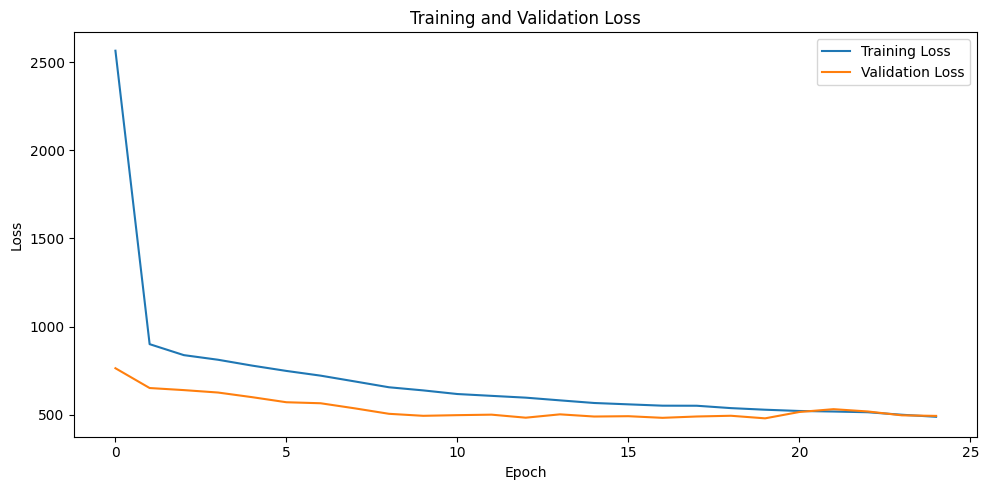

In [16]:
# plotting training history
plot_training_history(history)

Evaluating the LSTM model

In [17]:
lstm_predictions = lstm_model.predict(x_test_seq).flatten()

lstm_metrics = evaluate_regression_model(
    y_true=y_test_seq,
    y_pred=lstm_predictions,
)

lstm_metrics

124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


{'MAE': 14.72, 'RMSE': 22.82, 'MAPE': 18.33, 'R2': 0.66}

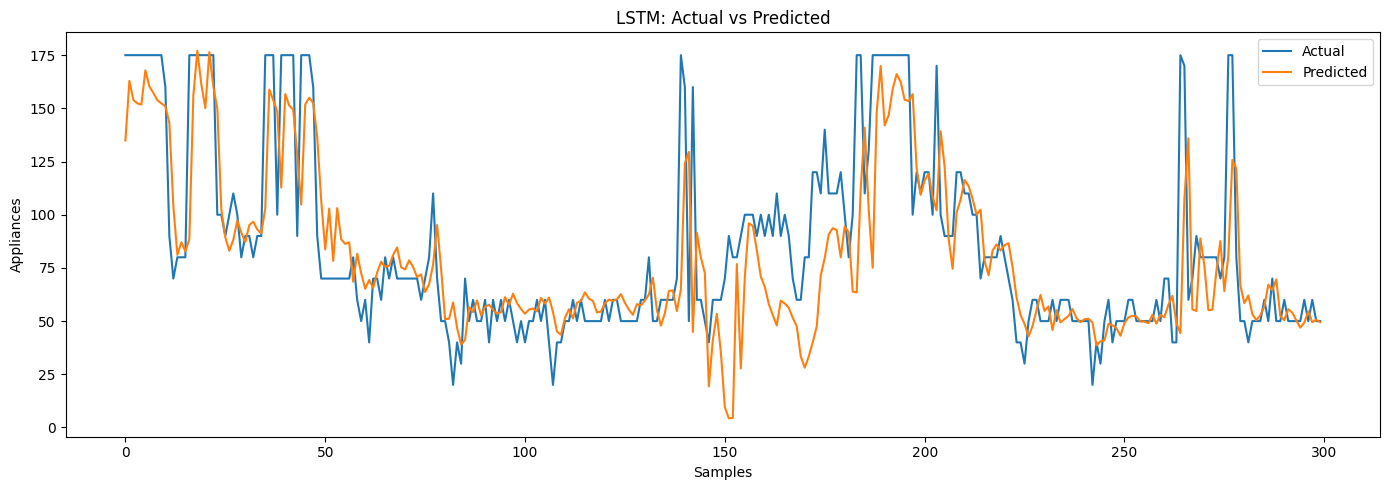

In [18]:
# plotting LSTM model predictions
plot_actual_vs_predicted(
    y_true=y_test_seq[:300],
    y_pred=lstm_predictions[:300],
    title="LSTM: Actual vs Predicted",
    file_name="lstm_actual_vs_predicted.png"
)

### Model Comparison 

In [19]:
comparison_df = create_model_comparison_dataframe(
    linear_metrics=linear_metrics,
    random_forest_metrics=random_forest_metrics,
    lstm_metrics=lstm_metrics,
)

comparison_df

,model,MAE,RMSE,MAPE,R2
0,Linear Regression,11.61,18.01,14.60,0.79
1,Random Forest,11.53,17.73,14.81,0.79
2,LSTM,14.72,22.82,18.33,0.66


In [20]:
# saving comparison table
save_model_comparison_dataframe(
    comparison_df=comparison_df,
    file_name="model_comparison_results.csv"
)